# Read data

In [45]:
import pandas as pd

df = pd.read_csv('data/transfers.csv')
df.head()


,player_id,transfer_date,transfer_season,from_club_id,to_club_id,from_club_name,to_club_name,transfer_fee,market_value_in_eur,player_name
0,467994,2030-06-30,25/26,5621,749,Reggiana,FC Empoli,0.0,700000.0,Luca Belardinelli
1,1077560,2027-06-30,26/27,3060,683,Atromitos,Olympiacos,0.0,1000000.0,Stavros Pnevmonidis
2,739277,2027-05-30,26/27,42055,589,Genclik Gücü,Antalyaspor,0.0,NaN,Yannick Nkurunziza
3,1043003,2027-01-27,26/27,114,405,Besiktas,Aston Villa,0.0,5000000.0,Yasin Özcan
4,282727,2026-12-31,25/26,49283,605,FC Juárez,Aris Saloniki,0.0,6000000.0,Monchu


In [46]:
df['transfer_date'] = pd.to_datetime(df['transfer_date'])
df['transfer_fee'] = df['transfer_fee'].fillna(0)
df = df[df['from_club_id'] != df['to_club_id']]

In [47]:
df = df[df['transfer_date'] <= pd.Timestamp.today()]

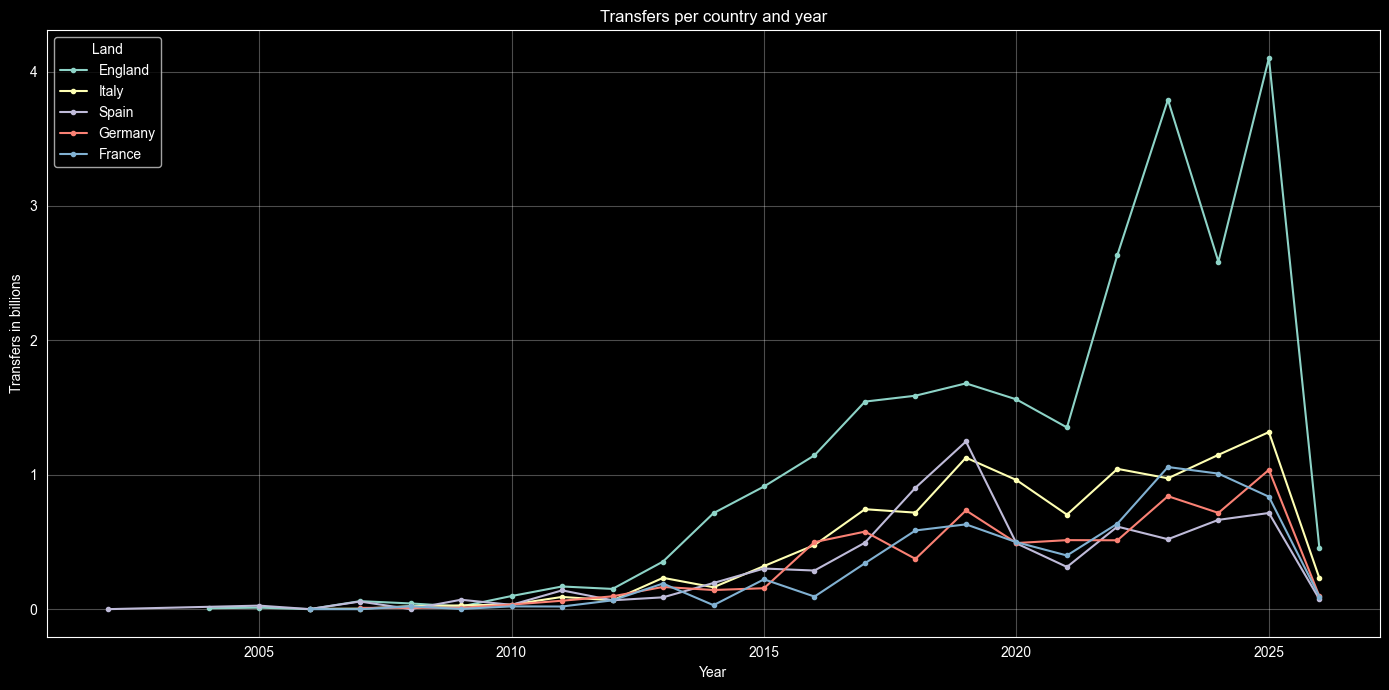

In [48]:
import matplotlib.pyplot as plt

# Clubs und Competitions laden für Länder-Zuordnung
clubs = pd.read_csv('data/clubs.csv')
competitions = pd.read_csv('data/competitions.csv')

# Kaufender Club (to_club_id) → Land zuordnen
df = df.merge(
    clubs[['club_id', 'domestic_competition_id']],
    left_on='to_club_id', right_on='club_id', how='left'
).drop(columns='club_id')

df = df.merge(
    competitions[['competition_id', 'country_name']],
    left_on='domestic_competition_id', right_on='competition_id', how='left'
).drop(columns='competition_id')

# Nur Zeilen mit bekanntem Land und transfer_fee > 0
df_clean = df.dropna(subset=['country_name'])
df_clean = df_clean[df_clean['transfer_fee'] > 0]

# Jahr extrahieren und pro Land/Jahr summieren
df_clean['year'] = df_clean['transfer_date'].dt.year

spending = df_clean.groupby(['year', 'country_name'])['transfer_fee'].sum().reset_index()

# Top 8 Länder nach Gesamtausgaben
top_countries = (
    spending.groupby('country_name')['transfer_fee'].sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

spending_top = spending[spending['country_name'].isin(top_countries)]

# Liniendiagramm (absichtlich schlechter Graph)
fig, ax = plt.subplots(figsize=(14, 7))

for country in top_countries:
    data = spending_top[spending_top['country_name'] == country]
    ax.plot(data['year'], data['transfer_fee'] / 1e9, marker='o', markersize=3, label=country)

ax.set_xlabel('Year')
ax.set_ylabel('Transfers in billions')
ax.set_title('Transfers per country and year')
ax.legend(title='Land')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()